# Classical vectorisation methods comparison — line-only synthetic data

This notebook generates **synthetic 64×64 raster images containing only straight vector lines**. There are **no curves** in this version.

Each image contains between **1 and 5 line items**. Lines may intersect and may extend beyond the visible image. The angle distribution is deliberately uneven: axis-aligned / 90-degree-increment lines are most common, then 45°, 60°, 30°, 20°, 10°, and finally other integer-degree angles.

The notebook compares these methods by raster reconstruction quality:

- Hough Transform
- Contour-based fitting
- Thinning / skeletonisation
- Run-graph based vectorisation
- Sparse-pixel RANSAC vectorisation
- Mesh-pattern local vectorisation

The important test is: after the method predicts vectors, do those vectors rasterise back into an image close to the original 64×64 raster?

## 1. Imports, settings, data generator, metrics, and method definitions

Foreground pixels are stored as `1`; background pixels are stored as `0`. For display, the notebook plots `1 - raster`, so the lines appear black on a white background.

In [1]:
import math, random, time
from dataclasses import dataclass
from typing import List, Dict, Tuple, Any

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None

IMG_SIZE = 64
LINE_WIDTH = 1.0
MIN_ITEMS = 1
MAX_ITEMS = 5
OVERHANG = 0.75
SEED = 12

N_TEST = 25
SHOW_SAMPLES = 5

random.seed(SEED)
np.random.seed(SEED)


def sample_weighted_angle_degrees():
    angle_groups = []
    angle_groups.append(("axis_90", [0, 90], 0.46))
    angle_groups.append(("diagonal_45", [45, 135], 0.20))
    angle_groups.append(("multiple_60", [60, 120], 0.11))
    angle_groups.append(("multiple_30", [30, 150], 0.08))
    angle_groups.append(("multiple_20", [20, 40, 80, 100, 140, 160], 0.06))
    used = set(sum([g[1] for g in angle_groups], []))
    mult10 = [a for a in range(0, 180, 10) if a not in used]
    angle_groups.append(("multiple_10", mult10, 0.05))
    used = used.union(mult10)
    rest = [a for a in range(180) if a not in used]
    angle_groups.append(("other_integer", rest, 0.04))
    labels, values, weights = zip(*angle_groups)
    group_index = np.random.choice(len(values), p=np.array(weights) / np.sum(weights))
    return int(np.random.choice(values[group_index])), labels[group_index]


def line_endpoints_from_center_angle(cx, cy, angle_deg, length):
    theta = math.radians(angle_deg)
    dx = math.cos(theta) * length / 2.0
    dy = math.sin(theta) * length / 2.0
    return cx - dx, cy - dy, cx + dx, cy + dy


def distance_to_segment_grid(x0, y0, x1, y1, img_size=IMG_SIZE):
    yy, xx = np.mgrid[0:img_size, 0:img_size]
    px = xx.astype(np.float32)
    py = yy.astype(np.float32)
    vx = x1 - x0
    vy = y1 - y0
    denom = vx * vx + vy * vy + 1e-9
    t = ((px - x0) * vx + (py - y0) * vy) / denom
    t = np.clip(t, 0.0, 1.0)
    projx = x0 + t * vx
    projy = y0 + t * vy
    return np.sqrt((px - projx) ** 2 + (py - projy) ** 2)


def rasterize_vectors(vectors, img_size=IMG_SIZE, line_width=LINE_WIDTH):
    mask = np.zeros((img_size, img_size), dtype=np.float32)
    for v in vectors:
        x0, y0, x1, y1 = v["x0"], v["y0"], v["x1"], v["y1"]
        d = distance_to_segment_grid(x0, y0, x1, y1, img_size)
        mask = np.maximum(mask, (d <= (line_width / 2.0 + 0.15)).astype(np.float32))
    return mask


def generate_line_only_sample(img_size=IMG_SIZE, min_items=MIN_ITEMS, max_items=MAX_ITEMS):
    n_items = np.random.randint(min_items, max_items + 1)
    vectors = []
    for _ in range(n_items):
        angle, angle_group = sample_weighted_angle_degrees()
        margin = img_size * OVERHANG
        cx = np.random.uniform(-margin, img_size - 1 + margin)
        cy = np.random.uniform(-margin, img_size - 1 + margin)
        length = np.random.uniform(img_size * 0.25, img_size * 2.4)
        x0, y0, x1, y1 = line_endpoints_from_center_angle(cx, cy, angle, length)
        vectors.append({
            "kind": "line", "x0": x0, "y0": y0, "x1": x1, "y1": y1,
            "angle_deg": angle, "angle_group": angle_group
        })
    raster = rasterize_vectors(vectors, img_size=img_size, line_width=LINE_WIDTH)
    # Reject almost empty samples and regenerate.
    if raster.sum() < 4:
        return generate_line_only_sample(img_size, min_items, max_items)
    return {"raster": raster, "vectors": vectors}


def show_synthetic_sample(sample):
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(1 - sample["raster"], cmap="gray", vmin=0, vmax=1)
    ax[0].set_title("64x64 raster input")
    ax[0].axis("off")
    ax[1].imshow(np.ones_like(sample["raster"]), cmap="gray", vmin=0, vmax=1)
    for v in sample["vectors"]:
        ax[1].plot([v["x0"], v["x1"]], [v["y0"], v["y1"]], linewidth=1)
    ax[1].set_xlim(0, IMG_SIZE - 1)
    ax[1].set_ylim(IMG_SIZE - 1, 0)
    ax[1].set_title("Original vectors")
    ax[1].axis("off")
    plt.show()


def raster_metrics(pred, target):
    pred_b = pred > 0.5
    target_b = target > 0.5
    tp = np.logical_and(pred_b, target_b).sum()
    fp = np.logical_and(pred_b, ~target_b).sum()
    fn = np.logical_and(~pred_b, target_b).sum()
    union = np.logical_or(pred_b, target_b).sum()
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (union + 1e-9)
    mae = np.mean(np.abs(pred.astype(np.float32) - target.astype(np.float32)))
    return {"iou": iou, "precision": precision, "recall": recall, "f1": f1, "mae": mae}


def plot_vectors_as_raster(vectors, title="vectors", img_size=IMG_SIZE):
    raster = rasterize_vectors(vectors, img_size=img_size)
    plt.figure(figsize=(4, 4))
    plt.imshow(1 - raster, cmap="gray", vmin=0, vmax=1)
    plt.title(title)
    plt.axis("off")
    plt.show()


def connected_components(binary):
    h, w = binary.shape
    visited = np.zeros_like(binary, dtype=bool)
    comps = []
    for y in range(h):
        for x in range(w):
            if not binary[y, x] or visited[y, x]:
                continue
            stack = [(x, y)]
            visited[y, x] = True
            pts = []
            while stack:
                px, py = stack.pop()
                pts.append((px, py))
                for dy in (-1, 0, 1):
                    for dx in (-1, 0, 1):
                        if dx == 0 and dy == 0:
                            continue
                        nx, ny = px + dx, py + dy
                        if 0 <= nx < w and 0 <= ny < h and binary[ny, nx] and not visited[ny, nx]:
                            visited[ny, nx] = True
                            stack.append((nx, ny))
            comps.append(np.array(pts, dtype=np.float32))
    return comps


def fit_segment_to_points(points):
    if len(points) < 2:
        return None
    pts = np.asarray(points, dtype=np.float32)
    mean = pts.mean(axis=0)
    centered = pts - mean
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    direction = vh[0]
    proj = centered @ direction
    p0 = mean + direction * proj.min()
    p1 = mean + direction * proj.max()
    if np.linalg.norm(p1 - p0) < 1.0:
        return None
    return {"kind": "line", "x0": float(p0[0]), "y0": float(p0[1]), "x1": float(p1[0]), "y1": float(p1[1])}


def line_distance_points(points, x0, y0, x1, y1):
    pts = np.asarray(points, dtype=np.float32)
    vx = x1 - x0
    vy = y1 - y0
    denom = math.sqrt(vx * vx + vy * vy) + 1e-9
    return np.abs(vy * pts[:, 0] - vx * pts[:, 1] + x1 * y0 - y1 * x0) / denom


def hough_transform_vectorise(raster, threshold_ratio=0.34, max_lines=12, distance_tol=1.25):
    binary = raster > 0.5
    ys, xs = np.nonzero(binary)
    if len(xs) < 2:
        return []
    thetas = np.deg2rad(np.arange(180))
    cos_t = np.cos(thetas)
    sin_t = np.sin(thetas)
    diag = int(np.ceil(np.sqrt(2) * max(raster.shape)))
    rhos = np.arange(-diag, diag + 1)
    acc = np.zeros((len(rhos), len(thetas)), dtype=np.int32)
    for x, y in zip(xs, ys):
        rho_vals = np.round(x * cos_t + y * sin_t).astype(int) + diag
        acc[rho_vals, np.arange(len(thetas))] += 1
    vectors = []
    remaining_points = np.column_stack([xs, ys]).astype(np.float32)
    acc_work = acc.copy()
    min_votes = max(5, int(threshold_ratio * np.sqrt(binary.sum())))
    for _ in range(max_lines):
        idx = np.unravel_index(np.argmax(acc_work), acc_work.shape)
        votes = acc_work[idx]
        if votes < min_votes or len(remaining_points) < 2:
            break
        rho = rhos[idx[0]]
        theta = thetas[idx[1]]
        # Direction along line is perpendicular to normal.
        dx = -math.sin(theta)
        dy = math.cos(theta)
        # A point on the line.
        x_base = rho * math.cos(theta)
        y_base = rho * math.sin(theta)
        # Choose support from the remaining foreground pixels.
        x_far0 = x_base - dx * 1000
        y_far0 = y_base - dy * 1000
        x_far1 = x_base + dx * 1000
        y_far1 = y_base + dy * 1000
        dists = line_distance_points(remaining_points, x_far0, y_far0, x_far1, y_far1)
        inlier_mask = dists <= distance_tol
        if inlier_mask.sum() < 4:
            acc_work[max(0, idx[0]-3):idx[0]+4, max(0, idx[1]-3):idx[1]+4] = 0
            continue
        inliers = remaining_points[inlier_mask]
        direction = np.array([dx, dy], dtype=np.float32)
        proj = inliers @ direction
        p0 = direction * proj.min() + np.array([x_base, y_base]) - direction * (np.array([x_base, y_base]) @ direction)
        p1 = direction * proj.max() + np.array([x_base, y_base]) - direction * (np.array([x_base, y_base]) @ direction)
        vectors.append({"kind": "line", "x0": float(p0[0]), "y0": float(p0[1]), "x1": float(p1[0]), "y1": float(p1[1])})
        remaining_points = remaining_points[~inlier_mask]
        acc_work[max(0, idx[0]-4):idx[0]+5, max(0, idx[1]-4):idx[1]+5] = 0
    return vectors


def contour_vectorise(raster, min_component_pixels=3):
    binary = raster > 0.5
    comps = connected_components(binary)
    vectors = []
    for comp in comps:
        if len(comp) < min_component_pixels:
            continue
        # Boundary pixels: foreground pixels touching background. Thin strokes are mostly boundary.
        boundary = []
        for x, y in comp.astype(int):
            neigh_foreground = 0
            for dy in (-1, 0, 1):
                for dx in (-1, 0, 1):
                    if dx == 0 and dy == 0:
                        continue
                    nx, ny = x + dx, y + dy
                    if 0 <= nx < binary.shape[1] and 0 <= ny < binary.shape[0] and binary[ny, nx]:
                        neigh_foreground += 1
            if neigh_foreground < 8:
                boundary.append((x, y))
        seg = fit_segment_to_points(np.array(boundary, dtype=np.float32) if boundary else comp)
        if seg is not None:
            vectors.append(seg)
    return vectors


def zhang_suen_thinning(binary):
    img = (binary > 0).astype(np.uint8).copy()
    changed = True
    h, w = img.shape
    while changed:
        changed = False
        to_remove = []
        for y in range(1, h - 1):
            for x in range(1, w - 1):
                if img[y, x] == 0:
                    continue
                p2 = img[y-1, x]; p3 = img[y-1, x+1]; p4 = img[y, x+1]; p5 = img[y+1, x+1]
                p6 = img[y+1, x]; p7 = img[y+1, x-1]; p8 = img[y, x-1]; p9 = img[y-1, x-1]
                neigh = [p2, p3, p4, p5, p6, p7, p8, p9]
                b = sum(neigh)
                a = sum((neigh[i] == 0 and neigh[(i + 1) % 8] == 1) for i in range(8))
                if 2 <= b <= 6 and a == 1 and p2 * p4 * p6 == 0 and p4 * p6 * p8 == 0:
                    to_remove.append((y, x))
        if to_remove:
            changed = True
            for y, x in to_remove:
                img[y, x] = 0
        to_remove = []
        for y in range(1, h - 1):
            for x in range(1, w - 1):
                if img[y, x] == 0:
                    continue
                p2 = img[y-1, x]; p3 = img[y-1, x+1]; p4 = img[y, x+1]; p5 = img[y+1, x+1]
                p6 = img[y+1, x]; p7 = img[y+1, x-1]; p8 = img[y, x-1]; p9 = img[y-1, x-1]
                neigh = [p2, p3, p4, p5, p6, p7, p8, p9]
                b = sum(neigh)
                a = sum((neigh[i] == 0 and neigh[(i + 1) % 8] == 1) for i in range(8))
                if 2 <= b <= 6 and a == 1 and p2 * p4 * p8 == 0 and p2 * p6 * p8 == 0:
                    to_remove.append((y, x))
        if to_remove:
            changed = True
            for y, x in to_remove:
                img[y, x] = 0
    return img.astype(bool)


def skeleton_graph_vectorise(raster, min_path_len=2):
    skel = zhang_suen_thinning(raster > 0.5)
    h, w = skel.shape
    coords = set(zip(*np.nonzero(skel)))  # y, x
    def neighbours(y, x):
        out = []
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                if dx == 0 and dy == 0:
                    continue
                ny, nx = y + dy, x + dx
                if (ny, nx) in coords:
                    out.append((ny, nx))
        return out
    nodes = {p for p in coords if len(neighbours(*p)) != 2}
    visited_edges = set()
    vectors = []
    for node in list(nodes):
        for nb in neighbours(*node):
            edge = tuple(sorted([node, nb]))
            if edge in visited_edges:
                continue
            path = [node, nb]
            visited_edges.add(edge)
            prev, cur = node, nb
            while cur not in nodes:
                nbs = [n for n in neighbours(*cur) if n != prev]
                if not nbs:
                    break
                nxt = nbs[0]
                visited_edges.add(tuple(sorted([cur, nxt])))
                path.append(nxt)
                prev, cur = cur, nxt
            if len(path) >= min_path_len:
                pts = np.array([(x, y) for y, x in path], dtype=np.float32)
                seg = fit_segment_to_points(pts)
                if seg is not None:
                    vectors.append(seg)
    # Handle loops or components with no endpoints/junctions.
    if not vectors:
        for comp in connected_components(skel):
            seg = fit_segment_to_points(comp)
            if seg is not None:
                vectors.append(seg)
    return vectors


def run_graph_vectorise(raster, min_run=2):
    binary = raster > 0.5
    h, w = binary.shape
    vectors = []
    # Horizontal runs.
    for y in range(h):
        xs = np.where(binary[y])[0]
        if len(xs) == 0:
            continue
        starts = [xs[0]]
        ends = []
        for i in range(1, len(xs)):
            if xs[i] != xs[i-1] + 1:
                ends.append(xs[i-1])
                starts.append(xs[i])
        ends.append(xs[-1])
        for x0, x1 in zip(starts, ends):
            if x1 - x0 + 1 >= min_run:
                vectors.append({"kind": "line", "x0": float(x0), "y0": float(y), "x1": float(x1), "y1": float(y)})
    # Vertical runs.
    for x in range(w):
        ys = np.where(binary[:, x])[0]
        if len(ys) == 0:
            continue
        starts = [ys[0]]
        ends = []
        for i in range(1, len(ys)):
            if ys[i] != ys[i-1] + 1:
                ends.append(ys[i-1])
                starts.append(ys[i])
        ends.append(ys[-1])
        for y0, y1 in zip(starts, ends):
            if y1 - y0 + 1 >= min_run:
                vectors.append({"kind": "line", "x0": float(x), "y0": float(y0), "x1": float(x), "y1": float(y1)})
    return vectors


def ransac_line_from_points(points, iterations=120, tolerance=1.1, min_inliers=5):
    if len(points) < 2:
        return None, None
    best_mask = None
    best_count = 0
    n = len(points)
    for _ in range(iterations):
        i, j = np.random.choice(n, 2, replace=False)
        p0, p1 = points[i], points[j]
        if np.linalg.norm(p1 - p0) < 1e-6:
            continue
        d = line_distance_points(points, p0[0], p0[1], p1[0], p1[1])
        mask = d <= tolerance
        count = int(mask.sum())
        if count > best_count:
            best_count = count
            best_mask = mask
    if best_mask is None or best_count < min_inliers:
        return None, None
    seg = fit_segment_to_points(points[best_mask])
    return seg, best_mask


def sparse_pixel_vectorise(raster, max_lines=10, tolerance=1.1):
    ys, xs = np.nonzero(raster > 0.5)
    points = np.column_stack([xs, ys]).astype(np.float32)
    vectors = []
    for _ in range(max_lines):
        if len(points) < 5:
            break
        seg, mask = ransac_line_from_points(points, iterations=150, tolerance=tolerance, min_inliers=5)
        if seg is None:
            break
        vectors.append(seg)
        points = points[~mask]
    return vectors


def mesh_pattern_vectorise(raster, cell_size=8, min_pixels=2):
    binary = raster > 0.5
    h, w = binary.shape
    vectors = []
    for y0 in range(0, h, cell_size):
        for x0 in range(0, w, cell_size):
            cell = binary[y0:y0+cell_size, x0:x0+cell_size]
            ys, xs = np.nonzero(cell)
            if len(xs) < min_pixels:
                continue
            pts = np.column_stack([xs + x0, ys + y0]).astype(np.float32)
            seg = fit_segment_to_points(pts)
            if seg is not None:
                vectors.append(seg)
    return vectors


METHODS = {
    "Hough Transform": hough_transform_vectorise,
    "Contour": contour_vectorise,
    "Skeletonisation": skeleton_graph_vectorise,
    "Run-graph": run_graph_vectorise,
    "Sparse-pixel RANSAC": sparse_pixel_vectorise,
    "Mesh-pattern": mesh_pattern_vectorise,
}


def run_all_methods(sample):
    rows = []
    outputs = {}
    target = sample["raster"]
    for name, fn in METHODS.items():
        start = time.perf_counter()
        vectors = fn(target)
        elapsed_ms = (time.perf_counter() - start) * 1000
        recon = rasterize_vectors(vectors)
        metrics = raster_metrics(recon, target)
        row = {"method": name, "vectors": len(vectors), "runtime_ms": elapsed_ms, **metrics}
        rows.append(row)
        outputs[name] = {"vectors": vectors, "raster": recon, "metrics": row}
    return rows, outputs


def plot_method_comparison(sample, outputs, max_methods=None):
    names = list(outputs.keys())
    if max_methods is not None:
        names = names[:max_methods]
    ncols = len(names) + 1
    fig, axes = plt.subplots(1, ncols, figsize=(3 * ncols, 3))
    axes[0].imshow(1 - sample["raster"], cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Input raster")
    axes[0].axis("off")
    for ax, name in zip(axes[1:], names):
        ax.imshow(1 - outputs[name]["raster"], cmap="gray", vmin=0, vmax=1)
        m = outputs[name]["metrics"]
        ax.set_title(f"{name}\nF1={m['f1']:.2f}, V={m['vectors']}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def plot_vectors_overlay(sample, outputs, method_name):
    vectors = outputs[method_name]["vectors"]
    plt.figure(figsize=(4, 4))
    plt.imshow(1 - sample["raster"], cmap="gray", vmin=0, vmax=1)
    for v in vectors:
        plt.plot([v["x0"], v["x1"]], [v["y0"], v["y1"]], linewidth=1)
    plt.xlim(0, IMG_SIZE - 1)
    plt.ylim(IMG_SIZE - 1, 0)
    plt.title(f"{method_name} vectors over input")
    plt.axis("off")
    plt.show()


def export_svg(vectors, filename="vectorised_output.svg", img_size=IMG_SIZE):
    lines = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{img_size}" height="{img_size}" viewBox="0 0 {img_size} {img_size}">']
    lines.append('<rect width="100%" height="100%" fill="white"/>')
    for v in vectors:
        lines.append(
            f'<line x1="{v["x0"]:.2f}" y1="{v["y0"]:.2f}" x2="{v["x1"]:.2f}" y2="{v["y1"]:.2f}" stroke="black" stroke-width="1" stroke-linecap="round"/>'
        )
    lines.append('</svg>')
    with open(filename, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))
    print(f"Saved {filename}")

## 2. Generate one line-only sample

The left plot is the raster input. The right plot shows the original synthetic vectors used to generate it.

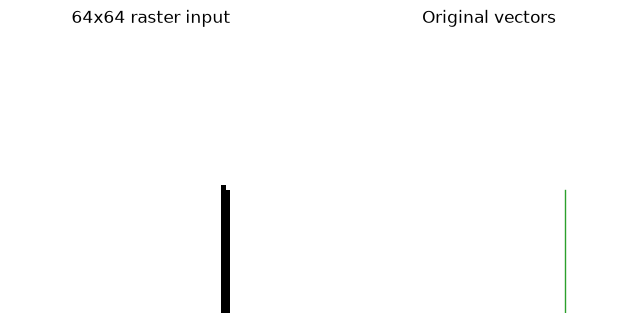

Generated vector items:
0 {'kind': 'line', 'x0': -6.13, 'y0': 27.86, 'x1': -6.13, 'y1': 45.87, 'angle_deg': 90, 'angle_group': 'axis_90'}
1 {'kind': 'line', 'x0': 36.22, 'y0': -79.27, 'x1': -38.27, 'y1': 9.51, 'angle_deg': 130, 'angle_group': 'multiple_10'}
2 {'kind': 'line', 'x0': 48.37, 'y0': 35.46, 'x1': 48.37, 'y1': 168.8, 'angle_deg': 90, 'angle_group': 'axis_90'}
3 {'kind': 'line', 'x0': -24.47, 'y0': 41.17, 'x1': -24.47, 'y1': 151.34, 'angle_deg': 90, 'angle_group': 'axis_90'}


In [2]:
sample = generate_line_only_sample()
show_synthetic_sample(sample)

print("Generated vector items:")
for i, v in enumerate(sample["vectors"]):
    rounded = {k: (round(v[k], 2) if isinstance(v[k], float) else v[k]) for k in v}
    print(i, rounded)

## 3. Compare all vectorisation methods on one sample

Each method predicts line vectors, then those vectors are rasterised back to 64×64 and compared with the input raster.

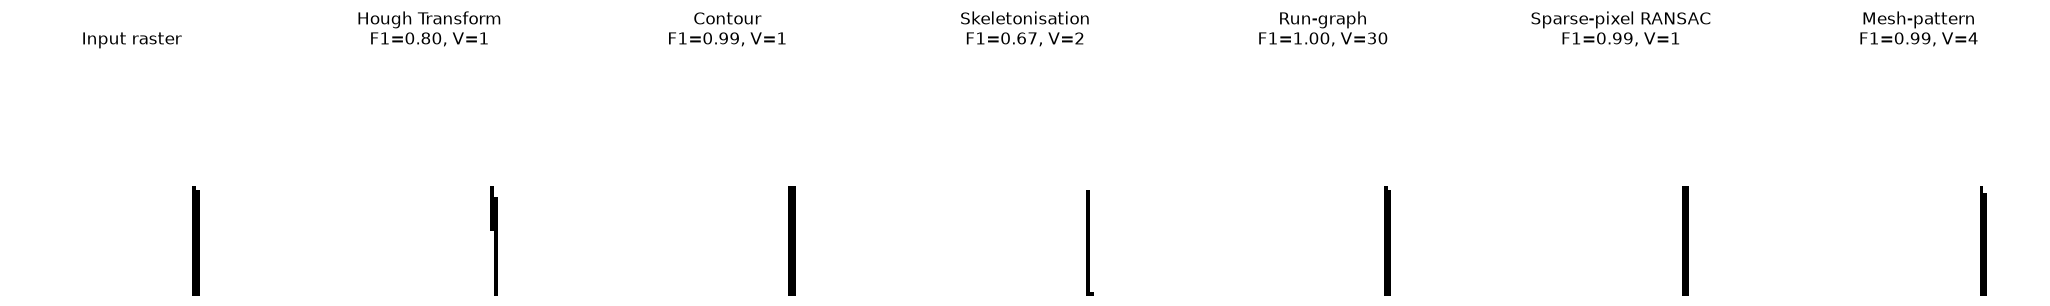

,method,vectors,runtime_ms,iou,precision,recall,f1,mae
3,Run-graph,30,0.2024,1.000000,1.000000,1.000000,1.000000,0.000000
1,Contour,1,1.1553,0.982759,0.982759,1.000000,0.991304,0.000244
4,Sparse-pixel RANSAC,1,2.7685,0.982759,0.982759,1.000000,0.991304,0.000244
5,Mesh-pattern,4,0.2524,0.982456,1.000000,0.982456,0.991150,0.000244
0,Hough Transform,1,1.6181,0.666667,1.000000,0.666667,0.800000,0.004639
2,Skeletonisation,2,3.3143,0.508772,1.000000,0.508772,0.674419,0.006836


In [3]:
rows, outputs = run_all_methods(sample)
plot_method_comparison(sample, outputs)

if pd is not None:
    display(pd.DataFrame(rows).sort_values("f1", ascending=False))
else:
    for row in sorted(rows, key=lambda r: r["f1"], reverse=True):
        print(row)

## 4. Overlay predicted vectors over the input

This is useful because two methods can get similar raster scores while producing very different vector structures.

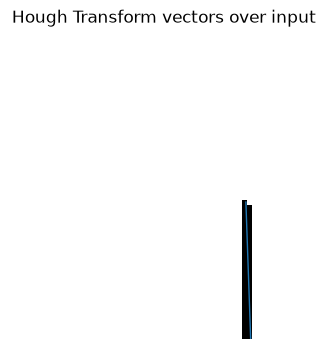

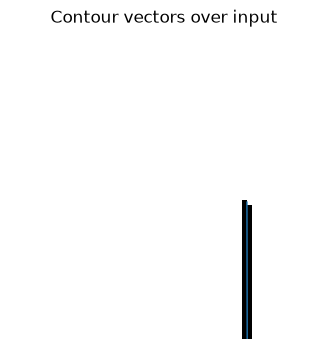

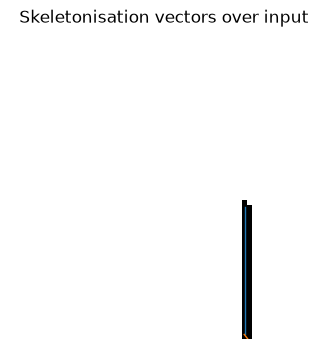

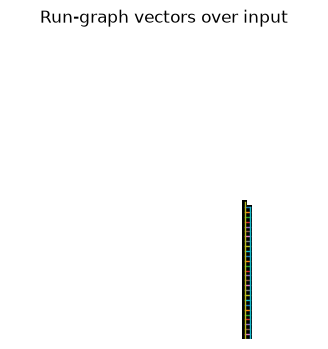

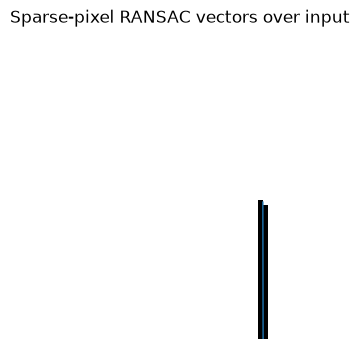

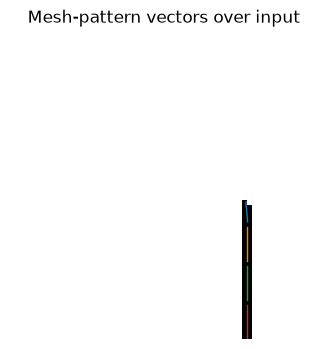

In [4]:
for method_name in METHODS:
    plot_vectors_overlay(sample, outputs, method_name)

## 5. Benchmark on multiple random line-only images

Adjust `N_TEST` in the first cell if you want more or fewer random test images.

In [5]:
all_rows = []
all_samples = []
all_outputs = []

for sample_index in range(N_TEST):
    sample_i = generate_line_only_sample()
    rows_i, outputs_i = run_all_methods(sample_i)

    for row in rows_i:
        row = dict(row)
        row["sample_index"] = sample_index
        row["true_vectors"] = len(sample_i["vectors"])
        all_rows.append(row)

    all_samples.append(sample_i)
    all_outputs.append(outputs_i)

if pd is not None:
    results_df = pd.DataFrame(all_rows)
    display(results_df.head())

    summary_df = (
        results_df
        .groupby("method")
        .agg({
            "iou": "mean",
            "precision": "mean",
            "recall": "mean",
            "f1": "mean",
            "mae": "mean",
            "vectors": "mean",
            "runtime_ms": "mean",
        })
        .sort_values("f1", ascending=False)
    )
    display(summary_df)
else:
    for name in METHODS:
        method_rows = [r for r in all_rows if r["method"] == name]
        print(name, "mean F1", np.mean([r["f1"] for r in method_rows]))

,method,vectors,runtime_ms,iou,precision,recall,f1,mae,sample_index,true_vectors
0,Hough Transform,2,1.7226,0.975,0.975,1.0,0.987342,0.000488,0,4
1,Contour,2,1.2740,1.000,1.000,1.0,1.000000,0.000000,0,4
2,Skeletonisation,2,2.6197,1.000,1.000,1.0,1.000000,0.000000,0,4
3,Run-graph,2,0.2296,1.000,1.000,1.0,1.000000,0.000000,0,4
4,Sparse-pixel RANSAC,2,11.3188,1.000,1.000,1.0,1.000000,0.000000,0,4


,iou,precision,recall,f1,mae,vectors,runtime_ms
method,,,,,,,
Run-graph,0.998473,1.000000,0.998473,0.999231,0.000029,50.36,0.223936
Sparse-pixel RANSAC,0.988800,0.993144,0.995564,0.994288,0.000371,1.80,8.439984
Mesh-pattern,0.951110,0.981305,0.966260,0.973223,0.001650,10.20,0.774312
Skeletonisation,0.855470,0.998788,0.856650,0.909907,0.005420,56.96,7.480616
Contour,0.858175,0.882762,0.865939,0.872379,0.007812,1.56,1.407516
Hough Transform,0.773729,0.925392,0.824285,0.863064,0.007617,1.96,1.886920


## 6. Show random benchmark examples

The title of each reconstruction includes F1 score and number of predicted vectors.

Sample 0: true vector count = 4


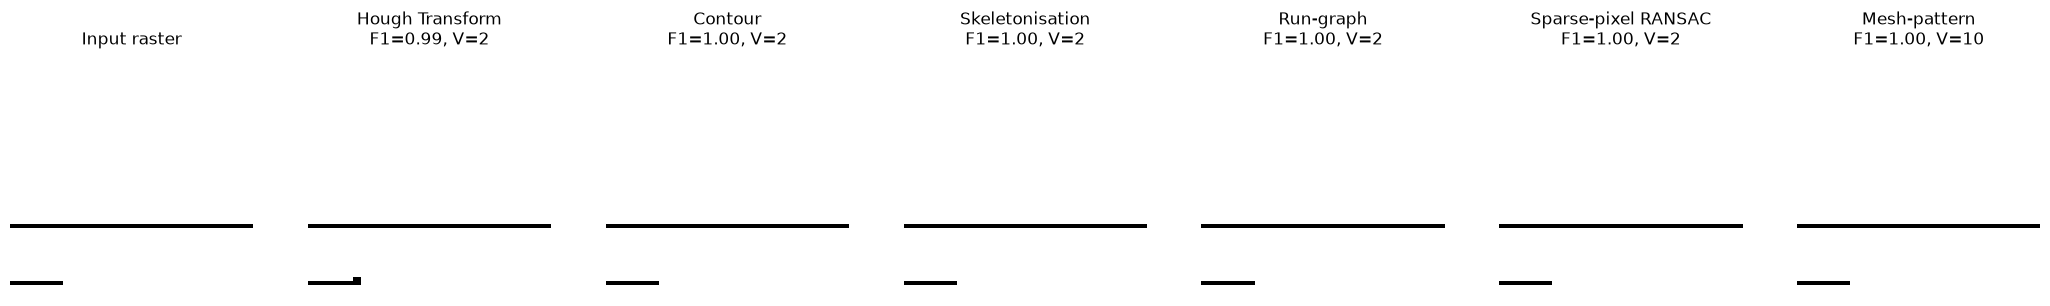

Sample 1: true vector count = 2


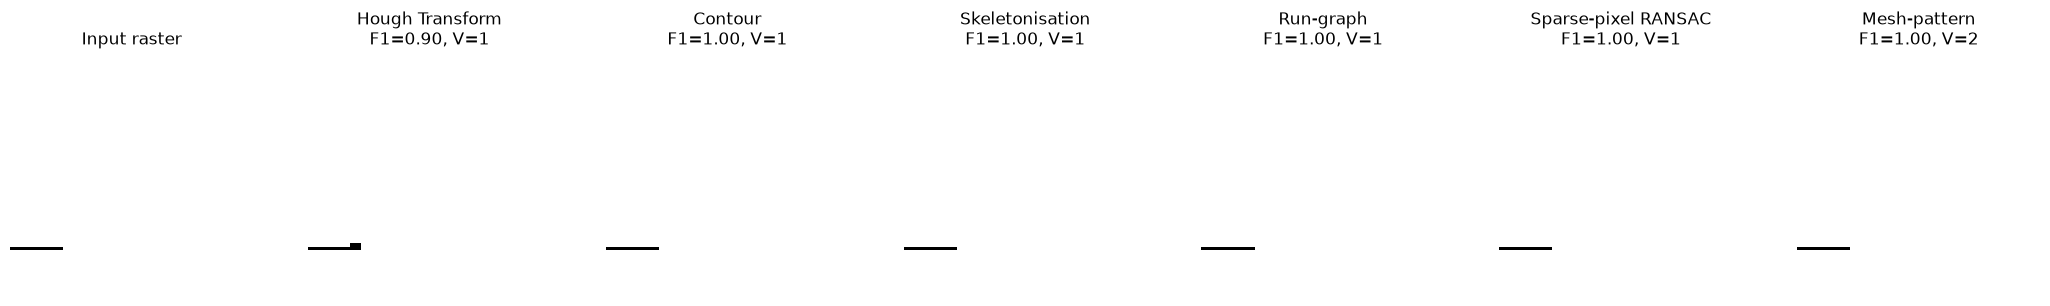

Sample 2: true vector count = 4


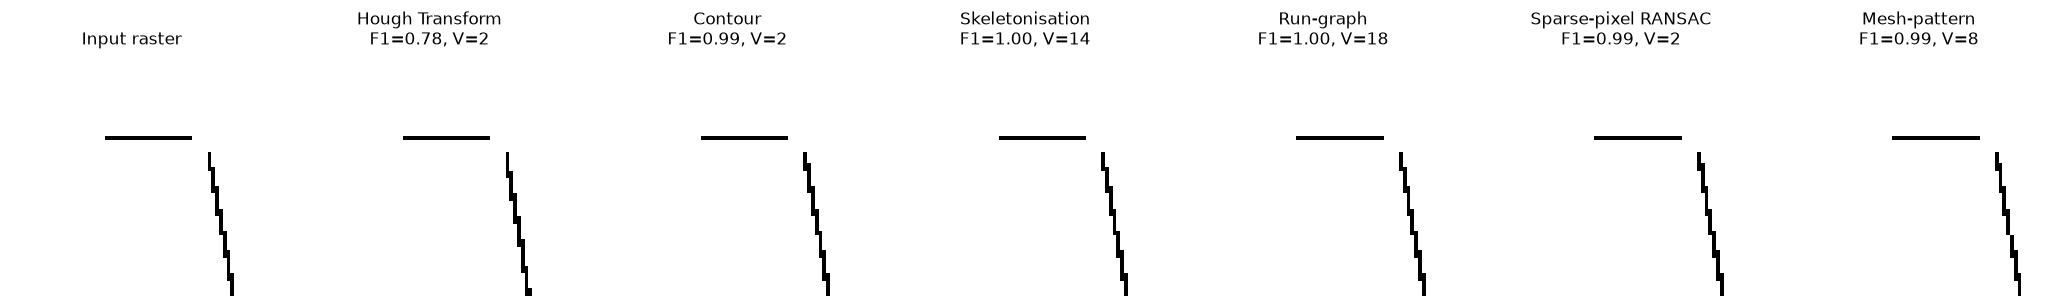

Sample 3: true vector count = 5


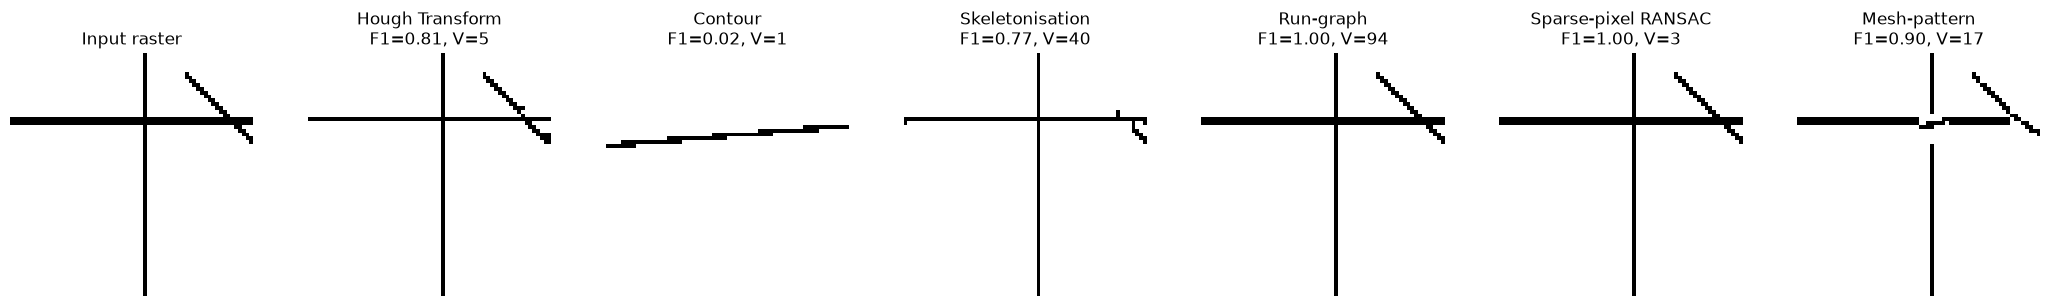

Sample 4: true vector count = 2


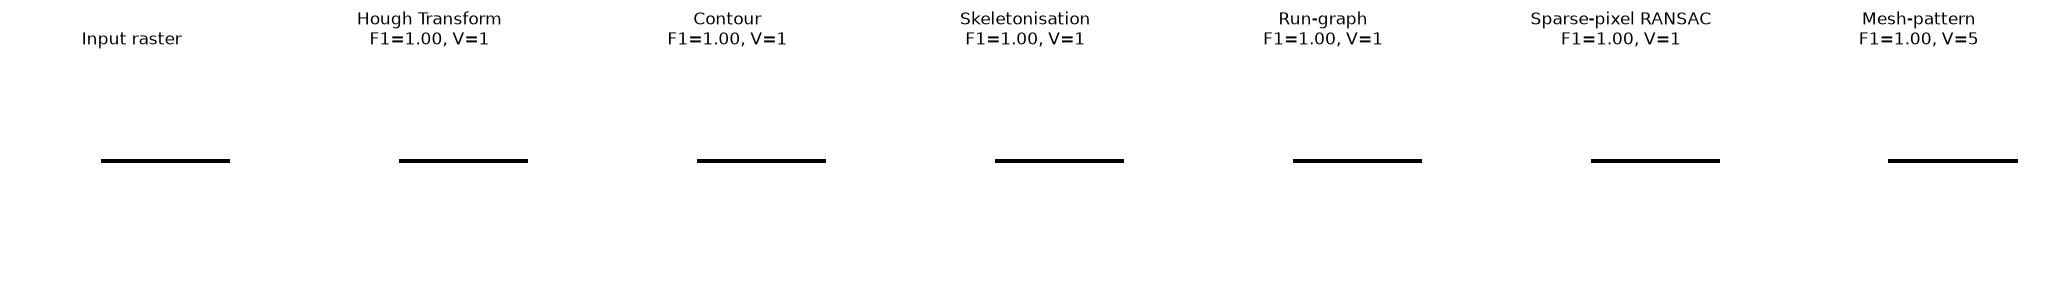

In [6]:
for i in range(min(SHOW_SAMPLES, len(all_samples))):
    print(f"Sample {i}: true vector count = {len(all_samples[i]['vectors'])}")
    plot_method_comparison(all_samples[i], all_outputs[i])

## 7. Export one result as SVG

Change the method name to export a different method's predicted vectors.

In [7]:
export_svg(outputs["Sparse-pixel RANSAC"]["vectors"], "sparse_pixel_ransac_output.svg")

Saved sparse_pixel_ransac_output.svg


## 8. Expected behaviour

- **Hough Transform** should perform well on long straight lines, but may over-detect or miss short segments at intersections.
- **Contour fitting** can fail when several lines touch because they become one connected component.
- **Skeletonisation** is often useful for centre-line recovery, especially at intersections, although it may fragment lines.
- **Run-graph** favours horizontal and vertical runs, so it should benefit from the deliberately high number of 0° and 90° lines.
- **Sparse-pixel RANSAC** is usually strong for this version because the data contains only straight lines.
- **Mesh-pattern** can produce close raster reconstructions using many short local vectors, but it is less compact as a vector representation.